In [1]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
import torch

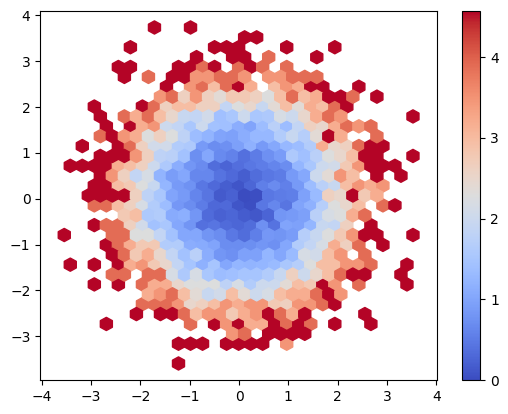

In [2]:
N=10000
data = np.random.randn(N, 2)
dummy_hb = plt.hexbin(data[:,0], data[:,1],
                C=np.ones(N), 
                reduce_C_function=lambda c: - np.log(np.sum(c)/N) ,
                cmap='coolwarm',
                gridsize=30,                
                )
plt.clf()
centers = dummy_hb.get_offsets()
counts = dummy_hb.get_array()


hb = plt.hexbin(centers[:,0], centers[:,1], C=counts - counts.min(), gridsize=30, cmap='coolwarm')
cb = plt.colorbar(hb)

plt.show()


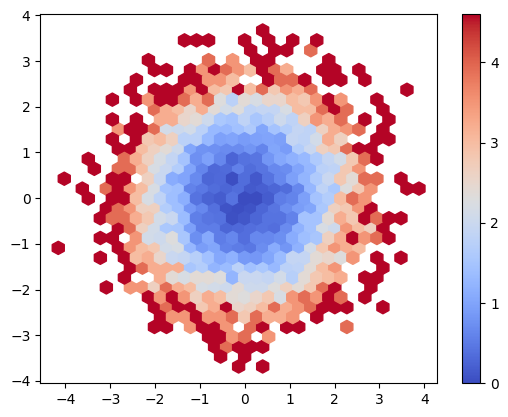

In [65]:
hb3 = plt.hexbin(centers[:,0], centers[:,1], C=counts - counts.min(), gridsize=30, cmap='coolwarm')
cb3 = plt.colorbar(hb3)

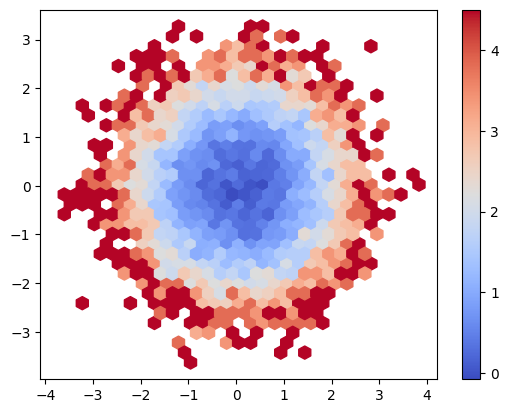

In [46]:
hb2 = plt.hexbin(centers[:,0], centers[:,1], C=counts, gridsize=30, cmap='coolwarm')
cb2 = plt.colorbar(hb2)

In [44]:
counts.min(), counts.max()

(-0.0749013081731178, 4.499809670330264)

In [28]:
# load the chignolin initial pdb
protein = md.load("/home/dunne/boltz-likelihoods/notebooks/chignolin_model_0.pdb")
num_noising_frames = 50
noising_traj = np.zeros((num_noising_frames, protein.n_atoms, 3))
noising_traj[0] = protein.xyz[0]
noising_traj[0] -= noising_traj[0].mean()  # normalize to have mean of 0
target_std = noising_traj[0].std() 
for i in range(1, num_noising_frames):
    next_point = noising_traj[i-1] + np.random.normal(scale=0.1, size=noising_traj[i-1].shape)    
    next_point -= next_point.mean()  # normalize to have mean of 0
    next_point *= target_std /next_point.std()  # rescale to have the same std as the denoised point
    noising_traj[i] = next_point

/tmp/ipykernel_537705/989600285.py:7: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(noising_traj[i, :, 0], noising_traj[i, :, 1], noising_traj[i, :, 2], s=1, c=cmap(i/num_noising_frames))


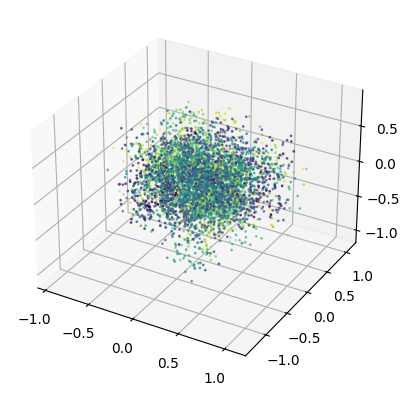

In [29]:
# plot the noising figure using matplotlib 3d scatter
# color according to frame number and a cmap
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
cmap = plt.get_cmap('viridis')
for i in range(num_noising_frames):
    ax.scatter(noising_traj[i, :, 0], noising_traj[i, :, 1], noising_traj[i, :, 2], s=1, c=cmap(i/num_noising_frames))
plt.show()

In [30]:
noise_traj = md.Trajectory(noising_traj, protein.topology)
noise_traj.save_pdb("noising_traj.pdb")

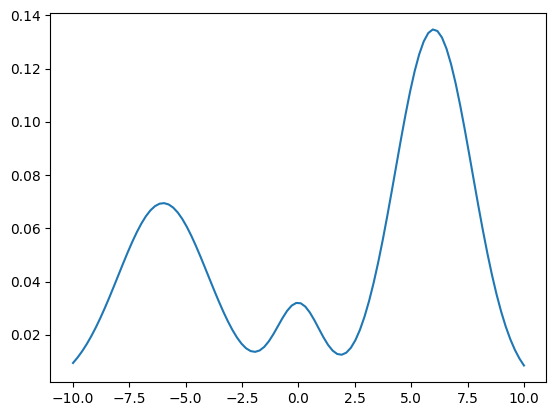

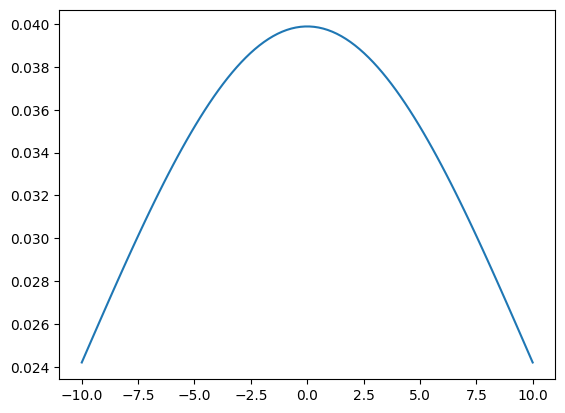

In [56]:
gmm = torch.distributions.MixtureSameFamily(
    mixture_distribution=torch.distributions.Categorical(logits=torch.tensor([3.5, 2, 4])),
    component_distribution=torch.distributions.Normal(loc=torch.tensor([-6.0, 0.0, 6.0]), scale=torch.tensor([2.0, 1.0, 1.7]))
)
fig, ax = plt.subplots()
ax.plot(np.linspace(-10, 10, 100), np.exp(gmm.log_prob(torch.linspace(-10, 10, 100))))

latent = torch.distributions.Normal(loc=torch.tensor(0.0), scale=torch.tensor(10.0))
fig, ax = plt.subplots()
ax.plot(np.linspace(-10, 10, 100), np.exp(latent.log_prob(torch.linspace(-10, 10, 100))))

In [45]:
samples = gmm.sample((100,))
rep_samples = samples.view(-1, 1).repeat(1,3)
orig_mode = gmm.component_distribution.log_prob(rep_samples).argmax(-1)


def euler_maruyama(f, g, x0, t_span, n_steps, forward=True, seed=None):
    """
    Euler-Maruyama integrator for SDEs of the form:
    dX_t = f(X_t, t)dt + g(X_t, t)dW_t
    
    Parameters:
    -----------
    f : callable
        Drift function f(x, t)
    g : callable  
        Diffusion function g(x, t)
    x0 : float
        Initial condition
    t_span : tuple
        Time span (t_start, t_end)
    dt : float
        Time step size
    forward : bool, optional
        If True, integrates forward in time; if False, backward in time. t_start < t_end always, if forward is False the integration is done from t_end to t_start.
    n_steps : int
        Number of time steps to take
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    t : ndarray
        Time points
    x : ndarray
        Solution values
    """
    if seed is not None:
        torch.random.seed(seed)
    t_start, t_end = t_span
    dt = torch.tensor((t_end - t_start) / n_steps, dtype=torch.float32)
    t = torch.linspace(t_start, t_end, n_steps, dtype=torch.float32)
    n_steps = len(t)
    
    # Generate Brownian motion increments
    dW = torch.randn((n_steps - 1,) + x0.shape, dtype=torch.float32) * torch.sqrt(dt)

    # Initialize trajectory list and add initial condition
    traj_list = [x0]

    # Euler-Maruyama iteration
    x_current = x0
    for i in range(n_steps - 1):
        t_curr = t[i] if forward else t[n_steps - 1 - i]
        x_next = x_current + f(x_current, t_curr) * dt + g(x_current, t_curr) * dW[i]
        traj_list.append(x_next)
        x_current = x_next
    
    # Stack into tensor
    traj = torch.stack(traj_list, dim=-1)

    return t, traj

batch_em = torch.vmap(euler_maruyama, in_dims=(None, None, 0, None, None), out_dims=(None, 0), randomness="different")
drift = lambda x, t: torch.zeros_like(x)
diffusion = lambda x, t: (2*t).sqrt()

t, traj = batch_em(drift, diffusion, samples.view(-1,1), (0.0, 10.0), 200)


[]

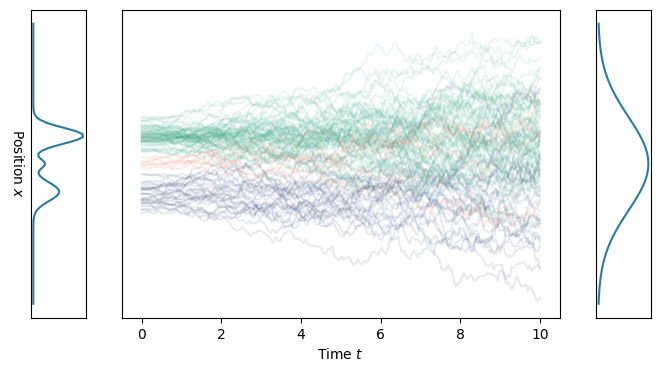

In [82]:
scale = 0.002
fig, ax = plt.subplots(1,3, sharey=True, figsize=(8,4), width_ratios=[0.1,0.8,0.1])
cmap = plt.get_cmap("tab10")
colors = ['#1b346c','#f54b1a','#43AA8B','#F9C74F', '#01abe9', '#277DA1','#6a040f']
for i in range(traj.shape[0]):
    ax[1].plot(t, traj[i,0,:].detach().numpy(), color=colors[orig_mode[i]], alpha=0.1)
ax[1].set_yticks([])
ax[1].set_xlabel(r"Time $t$")

ax[0].plot(np.exp(gmm.log_prob(torch.linspace(-30, 30, 100))), np.linspace(-30, 30, 100), c=colors[-2], label=r"$p(x)$")
# ax[0].plot(-scale * gmm.log_prob(torch.linspace(-30, 30, 100)), np.linspace(-30, 30, 100), c=colors[1], label=r"$U(x)$", linestyle="dashed")
ax[0].set_xticks([])
ax[0].set_ylabel(r"Position $x$", rotation=-90, labelpad=15)
ax[2].plot(np.exp(latent.log_prob(torch.linspace(-30, 30, 100))), np.linspace(-30, 30, 100), c=colors[-2], label=r"$p(z)$")
# ax[2].plot(-scale * latent.log_prob(torch.linspace(-30, 30, 100)), np.linspace(-30, 30, 100), c=colors[1], label=r"$U(z)$", linestyle="dashed")
ax[2].set_xticks([])